In [1]:
import streamlit as st

In [2]:
import google.generativeai as genai

In [3]:
import pandas as pd

In [4]:
from PIL import Image
import json

In [41]:
api_key = "<api_key>" #check in the receipts folder locally for my own api key

In [42]:
genai.configure(api_key=api_key)

In [43]:
model = genai.GenerativeModel('gemini-2.0-flash-001')

In [44]:
import pprint

In [45]:
for model in genai.list_models():
    pprint.pprint(model)

Model(name='models/embedding-gecko-001',
      base_model_id='',
      version='001',
      display_name='Embedding Gecko',
      description='Obtain a distributed representation of a text.',
      input_token_limit=1024,
      output_token_limit=1,
      supported_generation_methods=['embedText', 'countTextTokens'],
      temperature=None,
      max_temperature=None,
      top_p=None,
      top_k=None)
Model(name='models/gemini-2.5-flash',
      base_model_id='',
      version='001',
      display_name='Gemini 2.5 Flash',
      description=('Stable version of Gemini 2.5 Flash, our mid-size multimodal model that '
                   'supports up to 1 million tokens, released in June of 2025.'),
      input_token_limit=1048576,
      output_token_limit=65536,
      supported_generation_methods=['generateContent',
                                    'countTokens',
                                    'createCachedContent',
                                    'batchGenerateContent'],
     

In [39]:
def analyze_receipt(model,img):
    """
    Analyzes a receipt image using the Gemini Pro Vision model - This didn't support generateContent()
    So using Gemini 1.5 Flash Latest 
    """
    if not img:
        return None

    try:
        #model = genai.GenerativeModel('gemini-2.0-flash-001')
        
        # Open the image file
        #img = Image.open(image_file)

        # The prompt is crucial. It instructs the model to act as an expert
        # receipt parser and to return structured JSON.
        prompt = """
        You are an expert receipt analyzer specializing in UK supermarket receipts.
        Analyze the provided receipt image and extract the following information for each line item:
        1.  'quantity': The number of items purchased for this item
        2.  'Date': The date of purchase as printed on the bill - in the format dd/mm/yyyy
        3.  'item': The full description of the product purchased.
        4.  'price': The price of the item as a float.
        5.  'category': A relevant category for the item (e.g., 'Groceries','Groceries - Meat','Groceries - Dairy', 'Fruits', 'Vegetables', 'Snacks', 'Drinks', 'Household', 'Toiletries', 'Bakery', 'Alcohol').
        6.  'Store': The name of the store where the purchase was made

        Please return the output as a single valid JSON object containing a single key "items" which is a list of all extracted items.
        Do not include non-product lines like 'TOTAL', 'Subtotal', 'Card Payment', 'VAT'.
        Focus only on the actual products purchased and the savings denoted by negative price value. Mark these categories as 'Store Savings'.

        Example format:
        {
          "items": [
            { "quantity": 1, "Date": "02/03/2024", "item": "TESCO BANANAS 5 PACK", "price": 1.20, "category": "Fruits" , "Store": "Tesco"},
            { "quantity": 1, "Date": "02/03/2024", "item": "Tesco Lamb Chops 300g", "price": 4.90, "category": "Groceries - Meat", "Store": "Tesco"},
            { "quantity": 1, "Date": "02/03/2024", "item": "Onken Natural Set Yogurt 1kg", "price": 2.50, "category": "Groceries - Dairy", "Store": "Tesco"},
            { "quantity": 1, "Date": "02/03/2024", "item": "Hovis Wholemeal Bread", "price": 1.50, "category": "Bakery", "Store": "Tesco"}
          ]
        }
        """

        # Make the API call
        response = model.generate_content([prompt, img])
        
        # Clean up the response to extract only the JSON part
        # LLMs can sometimes add markdown formatting (```json ... ```)
        cleaned_response = response.text.strip().replace('```json', '').replace('```', '')
        
        return json.loads(cleaned_response)

    except Exception as e:
        #st.error(f"An error occurred during analysis: {e}")
        print("An error occurred during analysis:",e)
        #st.error("Please ensure your API key is correct and has access to the Gemini API.")
        print("Please ensure your API key is correct and has access to the Gemini API.")
        # Print the raw response for debugging if something goes wrong
        #st.text_area("Raw API Response for Debugging", value=response.text if 'response' in locals() else "No response received.", height=200)
        #print("Raw API Response for Debugging",response.text)
        return None

In [20]:
import sqlite3

In [79]:
# 1. Connect to the database (it will be created if it doesn't exist)
conn = sqlite3.connect('supermarket_spending_uk.db')
cursor = conn.cursor()

In [80]:
# 2. Create the table with your specified schema
#cursor.execute('''
#DROP TABLE IF EXISTS spending
#''')
#conn.commit()
cursor.execute('''
CREATE TABLE IF NOT EXISTS spending (
    quantity INTEGER NOT NULL,
    Date TEXT NOT NULL,
    item TEXT NOT NULL,
    price REAL NOT NULL,
    category TEXT,
    Store TEXT,
    filename TEXT
)
''')
conn.commit()

# 3. Insert a receipt
#(1, '12/08/2025', 'Tesco Whole Milk 2L', 1.65, 'Groceries - Dairy', 'Tesco')
data = pd.DataFrame(result_data["items"])
data.to_sql('spending',conn,index=False,if_exists='append')
#cursor.execute('''
#INSERT INTO spending (quantity, purchase_date, item, price, category, store)
#VALUES (?, ?, ?, ?, ?, ?)
#''', data)
conn.commit()

# 4. Load data into a pandas DataFrame for analysis
df = pd.read_sql_query("SELECT * FROM spending", conn)

# Close the connection
#conn.close()

In [81]:
df

,quantity,Date,item,price,category,Store,filename
0,1.0,30/06/2022,AFTER EIGHT DARK,2.00,Snacks,Sainsbury's,IMG_3214.jpg
1,6.0,30/06/2022,CLASSIC TOMATOES,0.80,Vegetables,Sainsbury's,IMG_3214.jpg
2,1.0,30/06/2022,JS LARGE GARLIC,0.65,Vegetables,Sainsbury's,IMG_3214.jpg
3,1.0,30/06/2022,JS FRESH MINT,0.55,Groceries,Sainsbury's,IMG_3214.jpg
4,1.0,30/06/2022,TTD EASY PEEL 600G,2.00,Fruits,Sainsbury's,IMG_3214.jpg
...,...,...,...,...,...,...,...
1266,1.0,26/10/2025,WR CI CORIANDER,1.09,Groceries - Herbs & Spices,Waitrose,IMG_4147.jpg
1267,1.0,26/10/2025,WR CHCK JAMBLYA SOUP,3.25,Groceries,Waitrose,IMG_4147.jpg
1268,1.0,26/10/2025,YEO YOG GREEK NATURA,1.93,Groceries - Dairy,Waitrose,IMG_4147.jpg
1269,1.0,26/10/2025,WR TRIP CHOC COOKIES,2.65,Bakery,Waitrose,IMG_4147.jpg


Sample code: in markdown
img = Image.open("IMG_3214.jpg")

result_data = analyze_receipt(img)

data = pd.DataFrame(result_data["items"])

filename = img.filename.split("/")[-1]

data.insert(6,"filename",filename)#[filename +"_" + str(n+1) for n in range(len(data))])

data

In [191]:
    print("Inserted file:", filename)

Inserted file: IMG_3200.jpg


In [26]:
import os
from os import listdir

In [77]:
count = 0
model = genai.GenerativeModel('gemini-2.0-flash-001')
for file in listdir(os.getcwd()):
    if(file.endswith('jpg') or file.endswith('JPG')):
        cursor.execute('''SELECT COUNT(*) FROM spending WHERE filename = ?''',(file,))
        if cursor.fetchall()[0][0] == 0:
            try:
                img = Image.open(file)
                result_data = analyze_receipt(model,img)
                data = pd.DataFrame(result_data["items"])
                filename = img.filename.split("/")[-1]
                data.insert(6,"filename",filename)#[filename +"_" + str(n+1) for n in range(len(data))])
                data.to_sql('spending',conn,index=False,if_exists='append')
                conn.commit()
                print(file," Inserted")
            except Exception as e:
                print(file," Not inserted due to error -> ",e)
                #break if you need to stop for an error and investigate
        else:
            print(file," already exists")
        count+=1
print(count)

IMG_3904.jpg  already exists
IMG_3870.jpg  already exists
IMG_3864.jpg  already exists
IMG_3858.jpg  already exists
IMG_4138.jpg  already exists
IMG_4139.jpg  already exists
IMG_3859.jpg  already exists
IMG_3865.jpg  already exists
IMG_3871.jpg  already exists
IMG_3905.jpg  already exists
IMG_3867.jpg  already exists
IMG_3873.jpg  already exists
IMG_3898.jpg  already exists
IMG_3899.jpg  already exists
IMG_3872.jpg  already exists
IMG_3866.jpg  already exists
IMG_3906.jpg  already exists
IMG_3902.jpg  already exists
IMG_3862.jpg  already exists
IMG_3876.JPG  already exists
IMG_3889.jpg  already exists
IMG_3888.jpg  already exists
IMG_3877.jpg  already exists
IMG_3903.jpg  already exists
IMG_3901.jpg  already exists
IMG_3849.jpg  already exists
IMG_3875.jpg  already exists
IMG_3861.jpg  already exists
IMG_3860.jpg  already exists
IMG_3874.jpg  already exists
IMG_3848.jpg  already exists
IMG_3900.jpg  already exists
IMG_3218.JPG  already exists
IMG_4205.jpg  already exists
IMG_3224.JPG  

In [84]:
filename

'IMG_4135.jpg'

In [85]:
df = pd.read_sql_query("SELECT * FROM spending", conn)

In [418]:
df_date = df

In [419]:
df_date['Date'] = pd.to_datetime(df_date['Date'],dayfirst=True)

In [420]:
count

85

In [421]:
data['Date'] = '15/10/2023'

In [422]:
data

,quantity,Date,item,price,category,Store,filename
0,1,15/10/2023,tortilla,14.2,Snacks,None,IMG_3896.jpg
1,1,15/10/2023,espresso cortial,111.0,Drinks,None,IMG_3896.jpg


In [264]:
data.to_sql('spending',conn,index=False,if_exists='append')
conn.commit()

In [279]:
cursor.execute('''SELECT COUNT(*) FROM spending WHERE category = ?''',('Groceries - Dairy',))

In [374]:
cursor.execute('''SELECT SUM(price),Date FROM spending GROUP BY Date ORDER BY Date ASC''')

In [35]:
from pandasql import sqldf

In [86]:
sqldf('''SELECT SUM(price),Date FROM df GROUP BY Date ORDER BY Date ASC''')

,SUM(price),Date
0,107.09,01/01/2025
1,81.39,01/02/2025
2,85.81,01/04/2024
3,27.62,01/06/2022
4,108.47,02/03/2024
...,...,...
139,24.16,30/08/2022
140,36.70,30/10/2022
141,130.55,30/12/2024
142,13.05,31/05/2022


In [112]:
df = pd.read_sql_query("SELECT * FROM spending", conn)

In [113]:
df

,quantity,Date,item,price,category,Store,filename
0,1.0,30/06/2022,AFTER EIGHT DARK,2.00,Snacks,Sainsbury's,IMG_3214.jpg
1,6.0,30/06/2022,CLASSIC TOMATOES,0.80,Vegetables,Sainsbury's,IMG_3214.jpg
2,1.0,30/06/2022,JS LARGE GARLIC,0.65,Vegetables,Sainsbury's,IMG_3214.jpg
3,1.0,30/06/2022,JS FRESH MINT,0.55,Groceries,Sainsbury's,IMG_3214.jpg
4,1.0,30/06/2022,TTD EASY PEEL 600G,2.00,Fruits,Sainsbury's,IMG_3214.jpg
...,...,...,...,...,...,...,...
2519,1.0,06/01/2026,Co Any 2 For £3.40,-0.40,Store Savings,Tesco,IMG_4135.jpg
2520,1.0,06/01/2026,Tesco Rocket Chillies 250g,1.70,Vegetables,Tesco,IMG_4135.jpg
2521,1.0,06/01/2026,Cadbury Biscoff Filled Egg 5x32g,4.00,Snacks,Tesco,IMG_4135.jpg
2522,1.0,06/01/2026,Co £2.95,-1.05,Store Savings,Tesco,IMG_4135.jpg


sqldf('''SELECT * FROM df WHERE Date = '21/01/2025' ''')

sqldf('''SELECT * FROM df WHERE quantity > 1 ''')#AND item LIKE '%@%' ''')

In [295]:
date_spend = cursor.fetchall()

In [296]:
date_spend

[(108.47000000000001, '02/03/2024'),
 (3.1, '02/08/2022'),
 (108.97000000000003, '05/06/2025'),
 (96.54000000000002, '05/07/2025'),
 (74.83999999999999, '05/11/2023'),
 (82.54999999999998, '05/12/2023'),
 (17.52, '06/07/2025'),
 (20.78, '06/08/2025'),
 (109.07000000000002, '07/07/2025'),
 (10.399999999999999, '10/07/2025'),
 (106.43, '11/06/2025'),
 (50.17999999999999, '12/08/2025'),
 (18.5, '13/02/2023'),
 (15.43, '13/07/2025'),
 (6.3, '13/08/2025'),
 (26.6, '13/09/2022'),
 (73.28, '13/11/2023'),
 (191.33, '14/07/2025'),
 (209.60999999999999, '15/10/2023'),
 (99.21, '16/12/2023'),
 (16.91, '18/02/2024'),
 (22.2, '22/05/2023'),
 (7.29, '22/06/2025'),
 (29.6, '22/07/2023'),
 (83.91000000000001, '22/07/2025'),
 (221.5, '23/04/2023'),
 (12.100000000000001, '23/05/2023'),
 (14.3, '23/12/2023'),
 (3.2, '24/07/2025'),
 (34.67, '24/09/2022'),
 (31.89, '25/07/2025'),
 (67.45, '26/06/2025'),
 (123.94999999999999, '26/11/2022'),
 (18.75, '27/11/2023'),
 (43.1, '28/09/2023'),
 (84.18, '29/10/2023

In [417]:
df.to_csv('Data_1708.csv')

In [101]:
now = pd.Timestamp.now().to_period('M')

In [102]:
begin = pd.Timestamp(year=2022,month=5,day=1).to_period('M')

In [103]:
begin

Period('2022-05', 'M')

In [104]:
L = pd.period_range(start = begin,end = now, freq='M').strftime('%Y-%m').tolist()

In [105]:
plot_data = pd.DataFrame(L,columns=['Months'])

In [106]:
df.index = df.Date

In [107]:
df_date

NameError: name 'df_date' is not defined

In [114]:
df['Date'] = pd.to_datetime(df['Date'])

/var/folders/pv/nyvv7t_x63db58y9_1r2thtw0000gn/T/ipykernel_16821/2394721818.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [115]:
df

,quantity,Date,item,price,category,Store,filename
0,1.0,2022-06-30,AFTER EIGHT DARK,2.00,Snacks,Sainsbury's,IMG_3214.jpg
1,6.0,2022-06-30,CLASSIC TOMATOES,0.80,Vegetables,Sainsbury's,IMG_3214.jpg
2,1.0,2022-06-30,JS LARGE GARLIC,0.65,Vegetables,Sainsbury's,IMG_3214.jpg
3,1.0,2022-06-30,JS FRESH MINT,0.55,Groceries,Sainsbury's,IMG_3214.jpg
4,1.0,2022-06-30,TTD EASY PEEL 600G,2.00,Fruits,Sainsbury's,IMG_3214.jpg
...,...,...,...,...,...,...,...
2519,1.0,2026-01-06,Co Any 2 For £3.40,-0.40,Store Savings,Tesco,IMG_4135.jpg
2520,1.0,2026-01-06,Tesco Rocket Chillies 250g,1.70,Vegetables,Tesco,IMG_4135.jpg
2521,1.0,2026-01-06,Cadbury Biscoff Filled Egg 5x32g,4.00,Snacks,Tesco,IMG_4135.jpg
2522,1.0,2026-01-06,Co £2.95,-1.05,Store Savings,Tesco,IMG_4135.jpg


In [116]:
group_sum = sqldf('''
SELECT SUM(price) AS Amount, strftime("%Y-%m",Date) AS Year_Month
FROM df
GROUP BY Year_Month
ORDER BY Year_Month ASC
''')

In [117]:
group_count = sqldf('''
SELECT COUNT(DISTINCT Date) AS Visits, strftime("%Y-%m",Date) AS Year_Month
FROM df
GROUP BY Year_Month
ORDER BY Year_Month ASC
''')

In [119]:
group_sum

,Amount,Year_Month
0,12.61,2020-06
1,204.14,2022-05
2,324.17,2022-06
3,40.24,2022-07
4,58.36,2022-08
5,61.27,2022-09
6,36.70,2022-10
7,264.09,2022-11
8,18.50,2023-02
9,221.50,2023-04


In [120]:
sum_price_months = pd.merge(left=plot_data,right=group_sum,left_on='Months',right_on='Year_Month',how='left')

In [121]:
count_visits_months = pd.merge(left=plot_data,right=group_count,left_on='Months',right_on='Year_Month',how='left')

In [122]:
sum_price_months

,Months,Amount,Year_Month
0,2022-05,204.14,2022-05
1,2022-06,324.17,2022-06
2,2022-07,40.24,2022-07
3,2022-08,58.36,2022-08
4,2022-09,61.27,2022-09
5,2022-10,36.70,2022-10
6,2022-11,264.09,2022-11
7,2022-12,NaN,NaN
8,2023-01,NaN,NaN
9,2023-02,18.50,2023-02


In [123]:
count_visits_months

,Months,Visits,Year_Month
0,2022-05,16.0,2022-05
1,2022-06,11.0,2022-06
2,2022-07,3.0,2022-07
3,2022-08,4.0,2022-08
4,2022-09,2.0,2022-09
5,2022-10,1.0,2022-10
6,2022-11,2.0,2022-11
7,2022-12,NaN,NaN
8,2023-01,NaN,NaN
9,2023-02,1.0,2023-02


In [124]:
import matplotlib.pyplot as plt
#%matplotlib inline
%matplotlib notebook

<IPython.core.display.Javascript object>


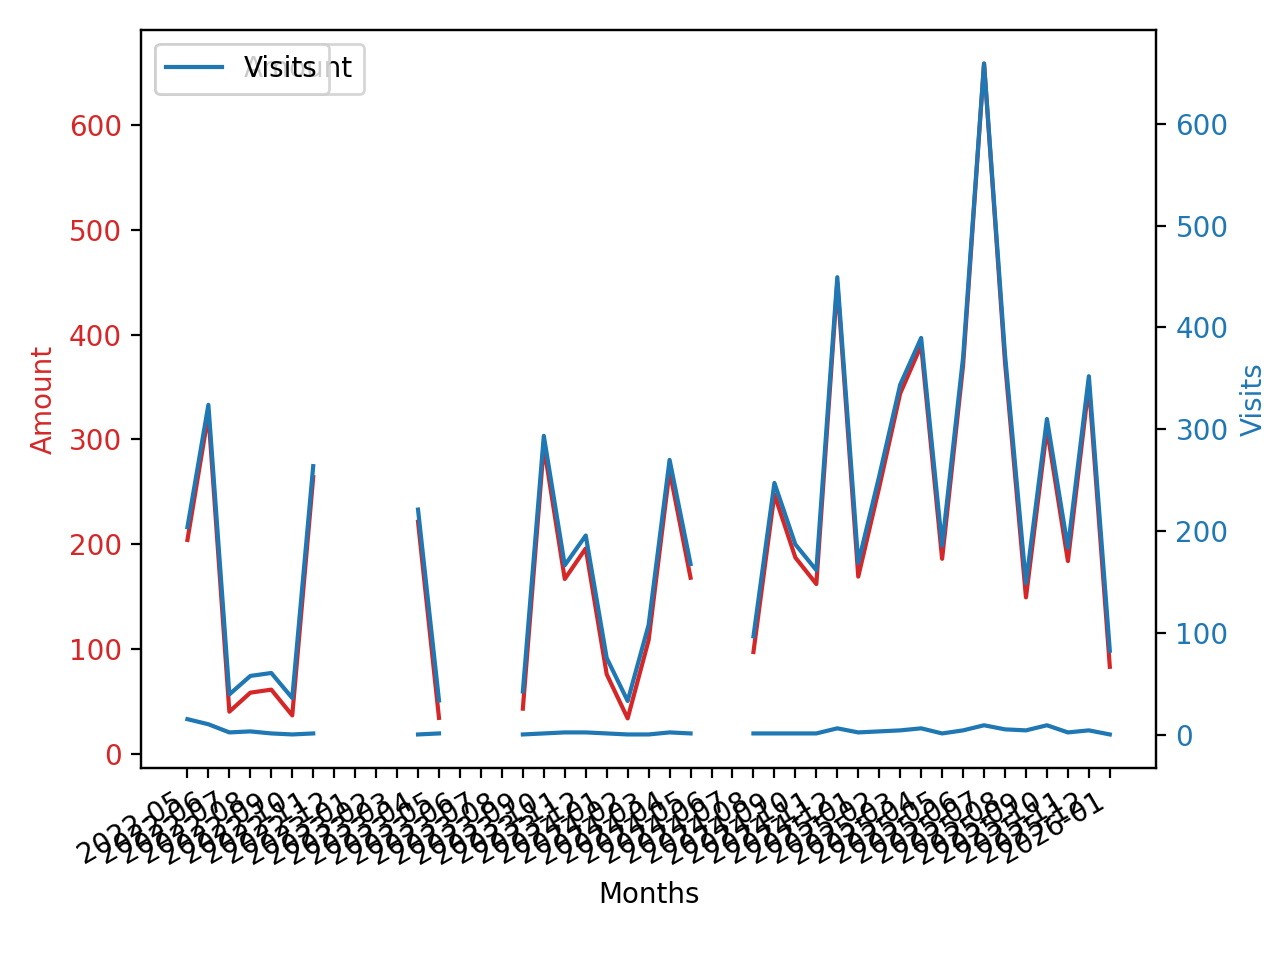

In [125]:
#plt.rcParams['figure.figsize'] = [18, 10]
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel('Months')
ax1.set_ylabel('Amount', color=color)
ax1.plot('Months','Amount',data=sum_price_months, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend()
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Visits', color=color)  # we already handled the x-label with ax1
ax2.plot('Months','Visits',data=count_visits_months, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend()
fig.tight_layout()  # otherwise the right y-label is slightly clipped
#plt.plot('Months','Amount',data=sum_price_months)
#plt.plot('Months','Visits',data=count_visits_months)
plt.gcf().autofmt_xdate()
plt.show()

In [126]:
plt.show()

In [127]:
from matplotlib import interactive

In [128]:
interactive(True)

In [129]:
plt.plot('Months','Amount',data=sum_price_months)

In [130]:
plt.show()